# Model Building

In [51]:
# Simple RNN : Recurrent Neural Network
# LSTM : Long Short Term Meomory
        # LSTM is more powerful than RNN & GRU
        # LSTM is costly (Time and memory consumption)
# GRU : Gated Recurrent Unit
        # GRU is extension of LSTM (light weight LSTM)
        # GRU is powerful than Simple RNN, also faster than LSTM
        # Consumed less resource, thats why more practical viable

# Sentiment Analysis using Simple RNN, LSTM, GRU

In [52]:
!pip install tensorflow
!pip install tensorflow-datasets
!pip install --upgrade jupyter ipywidgets

In [53]:
# Library

import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences  # Padding and Truncating
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout, Embedding

In [54]:
# !pip install importlib-resources

In [55]:
# import dataset : imdb dataset
dataset, info = tfds.load("imdb_reviews", split = ["train", "test"], as_supervised = True, with_info = True)

In [56]:
print(info)

tfds.core.DatasetInfo(
    name='imdb_reviews',
    full_name='imdb_reviews/plain_text/1.0.0',
    description="""
    Large Movie Review Dataset. This is a dataset for binary sentiment
    classification containing substantially more data than previous benchmark
    datasets. We provide a set of 25,000 highly polar movie reviews for training,
    and 25,000 for testing. There is additional unlabeled data for use as well.
    """,
    config_description="""
    Plain text
    """,
    homepage='http://ai.stanford.edu/~amaas/data/sentiment/',
    data_dir='C:\\Users\\Prikshit_Ishi\\tensorflow_datasets\\imdb_reviews\\plain_text\\1.0.0',
    file_format=tfrecord,
    download_size=Unknown size,
    dataset_size=129.83 MiB,
    features=FeaturesDict({
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
        'text': Text(shape=(), dtype=string),
    }),
    supervised_keys=('text', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
      

In [57]:
print(type(dataset[0]))

<class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>


In [58]:
train_data = dataset[0].as_numpy_iterator()

for _ in range(4):
    review, label = next(train_data)
    print(f" Review: {review.decode('utf-8')} \n Label : {"Postive" if label == 1 else "Negative"}")

 Review: This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it. 
 Label : Negative
 Review: I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette and having just eaten a lot. However on this occasion I fell asleep because the film was r

In [59]:
train_data, train_labels = [], []
test_data, test_labels = [], []

In [60]:
for text, label in dataset[0]:
    train_data.append(text.numpy().decode('utf-8'))
    train_labels.append(label.numpy())

In [61]:
for text, label in dataset[1]:
    test_data.append(text.numpy().decode('utf-8'))
    test_labels.append(label.numpy())

In [62]:
type(test_labels)

list

In [63]:
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)

In [64]:
train_data[0:2]

["This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.",
 'I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette and having just eaten a lot. However on this occasion I fell asleep because the film was rubbish. The plot development wa

In [65]:
# Tokenization
VOCAB_SIZE = 10000
tokenizer = Tokenizer(num_words = VOCAB_SIZE, oov_token = "<OOV>")
tokenizer.fit_on_texts(train_data)

In [66]:
# Convert the text into numerical values
train_sequences = tokenizer.texts_to_sequences(train_data)
test_sequences = tokenizer.texts_to_sequences(test_data)

In [67]:
# Padding & Truncating

MAX_LEN = 150

train_padded = pad_sequences(train_sequences, maxlen = MAX_LEN, padding = "post", truncating = "post")
test_padded = pad_sequences(test_sequences, maxlen = MAX_LEN, padding = "post", truncating = "post")

In [68]:
# Build the RNN models

rnn_model = Sequential([
                        Embedding(VOCAB_SIZE, 64),
                        SimpleRNN(64),
                        Dense(32, activation = 'relu'),
                        Dense(1, activation = 'sigmoid')
])

In [69]:
rnn_model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [70]:
rnn = rnn_model.fit(train_padded, train_labels, epochs = 5, batch_size = 64, verbose = 1)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.5028 - loss: 0.6965
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.5130 - loss: 0.6943
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.5668 - loss: 0.6746
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.6528 - loss: 0.6158
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.6619 - loss: 0.5796


# LSTM

In [71]:
lstm_model = Sequential([
                    Embedding(VOCAB_SIZE, 64),
                    LSTM(64),
                    Dense(32, activation = 'relu'),
                    Dense(1, activation = 'sigmoid')
])

In [72]:
lstm_model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [73]:
# total number of batch per epoch = total training samples / batch_size
lstm = lstm_model.fit(train_padded, train_labels, epochs = 5, batch_size = 64, verbose = 1)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 57ms/step - accuracy: 0.5639 - loss: 0.6737
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - accuracy: 0.5921 - loss: 0.6648
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.6903 - loss: 0.5970
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - accuracy: 0.8088 - loss: 0.4324
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0.8730 - loss: 0.3184


# GRU

In [74]:

gru_model = Sequential([
                        Embedding(VOCAB_SIZE, 64),
                        GRU(32),
                        Dense(32, activation = 'relu'),
                        Dense(1, activation = 'sigmoid')
])

In [75]:
gru_model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [76]:
gru = gru_model.fit(train_padded, train_labels, epochs = 5, batch_size = 64, verbose = 1)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step - accuracy: 0.5533 - loss: 0.6788
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.6500 - loss: 0.6247
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.7103 - loss: 0.5785
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.8524 - loss: 0.3435
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.9005 - loss: 0.2512


In [77]:
print(gru)

In [78]:
# Perfomance of SimpleRNN, LSTM, GRU on testing data
rnn_loss, rnn_acc = rnn_model.evaluate(test_padded, test_labels)
lstm_loss, lstm_acc = lstm_model.evaluate(test_padded, test_labels)
gru_loss, gru_acc = gru_model.evaluate(test_padded, test_labels)

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5960 - loss: 0.7034
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.8041 - loss: 0.4385
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.6599 - loss: 0.5686


Text(0, 0.5, 'accuracy')

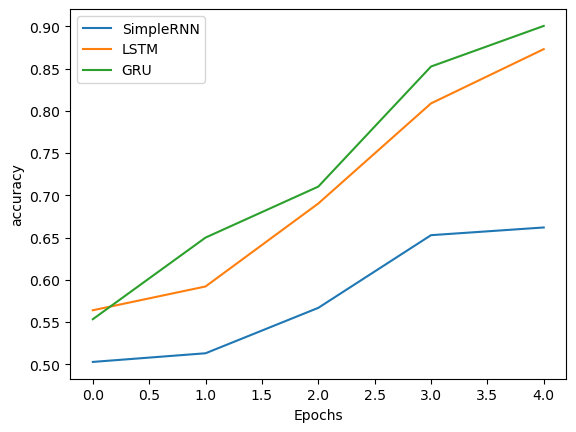

In [83]:
import matplotlib.pyplot as plt

plt.plot(rnn.history['accuracy'], label = 'SimpleRNN')
plt.plot(lstm.history['accuracy'],label = 'LSTM')
plt.plot(gru.history['accuracy'],label = 'GRU')

plt.legend()
plt.xlabel('Epochs')
plt.ylabel('accuracy')

In [117]:
# Test model on specific Review

sample_review_Dhurandar = ["""Very bad movie. Don't watch. I watch this movie with my friends.
                            They are asking their money back now. I insist to come for this movie.
                            Now they are searching me for killing"""]


sample_token = tokenizer.texts_to_sequences(sample_review_Dhurandar)
sample_padded = pad_sequences(sample_token, maxlen = 20, padding = "post", truncating = "post")

In [118]:
simple_rnn_predict = rnn_model.predict(sample_padded)[0][0]
output = "Positive" if simple_rnn_predict > 0.5 else "Negative"
print(output)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Negative


In [102]:
simple_rnn_predict

np.float32(0.20398319)